In [7]:
%load_ext autoreload
%autoreload 2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid
from prediction_analysis import confusion_matrix, plot_cm, prediction_vs_actual, most_confused, show_cm

device = torch.device('cuda:0')
model = torch.load('../../saved_models/05242024-benchmark-ResNet50-v5_10m/epoch-20.pt', map_location=device).module

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## basic datasets

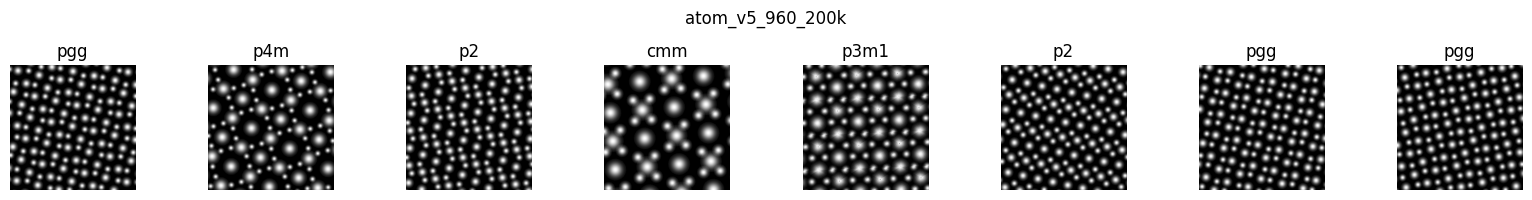

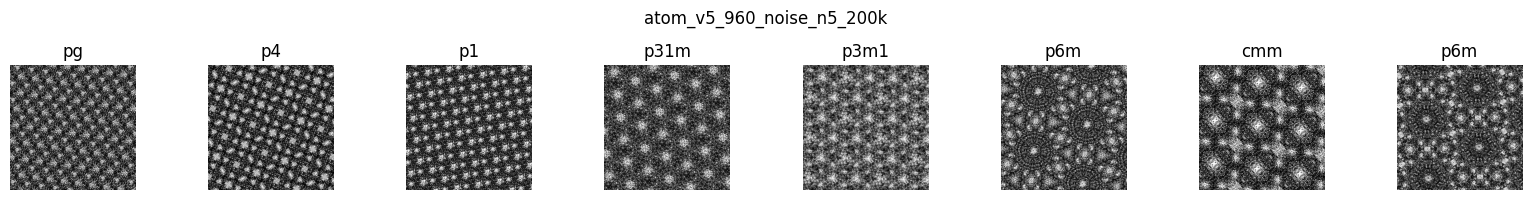

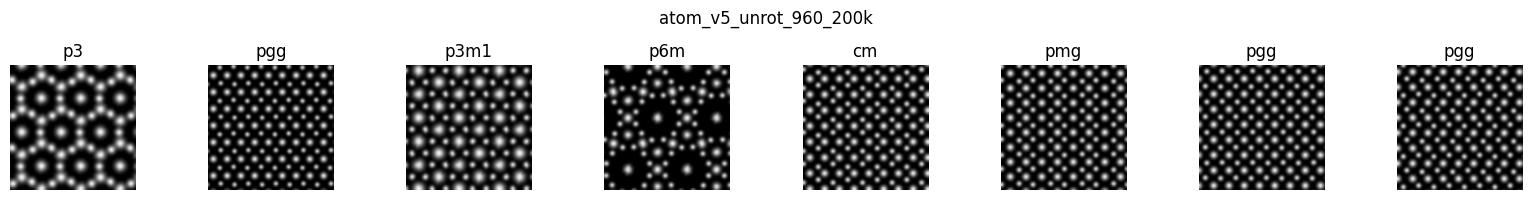

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# atom_v5_960_200k
atom_v5_200k_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_200k_dl = DataLoader(atom_v5_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_200k_dl, label_converter=label_converter, title='atom_v5_960_200k')

# atom_v5_noise_n5_200k
atom_v5_noise_n5_200k_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_noise_n5_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_noise_n5_200k_dl = DataLoader(atom_v5_noise_n5_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_noise_n5_200k_dl, label_converter=label_converter, title='atom_v5_960_noise_n5_200k')

# atom_v5_unrot_960_200k
atom_v5_unrot_960_200k_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_unrot_960_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_unrot_960_200k_dl = DataLoader(atom_v5_unrot_960_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_unrot_960_200k_dl, label_converter=label_converter, title='atom_v5_unrot_960_200k')
plt.show()

In [9]:
keywords = ['atom_v5_200k', 'atom_v5_noise_n5_200k', 'atom_v5_unrot_960_200k']
dl_list = [atom_v5_200k_dl, atom_v5_noise_n5_200k_dl, atom_v5_unrot_960_200k_dl]

for name, dl in zip(keywords, dl_list):
    cm = confusion_matrix(model, dl, symmetry_classes, device, n_batches='all')
    np.save(f'../../saved_results/Dataset_benchmark/resnet50-{name}_cm.npy', cm)

  0%|          | 0/399 [00:00<?, ?it/s]

100%|██████████| 399/399 [30:40<00:00,  4.61s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0


Accuracy for these batches: 84.09509803921569%


...

Accuracy for these batches: 97.29460784313726%


100%|██████████| 372/372 [33:36<00:00,  5.42s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0,11200.0


Accuracy for these batches: 86.43224789915966%


In [10]:
keywords = ['atom_v5_200k', 'atom_v5_noise_n5_200k', 'atom_v5_unrot_960_200k']
for k in keywords:
    file = glob.glob(f'../../saved_results/Dataset_benchmark/resnet50-{k}*.npy')[0]
    print(file)
    cm = np.load(file)
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    # plot_cm(cm, symmetry_classes, title=file.split('/')[-1].split('.')[0], cm_style='simple', fig_style='printing', font_size=4)

../../saved_results/Dataset_benchmark/resnet50-atom_v5_200k_cm.npy
Accuracy: 84.10%

../../saved_results/Dataset_benchmark/resnet50-atom_v5_noise_n5_200k_cm.npy
Accuracy: 97.29%

../../saved_results/Dataset_benchmark/resnet50-atom_v5_unrot_960_200k_cm.npy
Accuracy: 86.43%



## test with added random noise for atom ds ?

## cross validation benchmark on datasets with different unit cell size

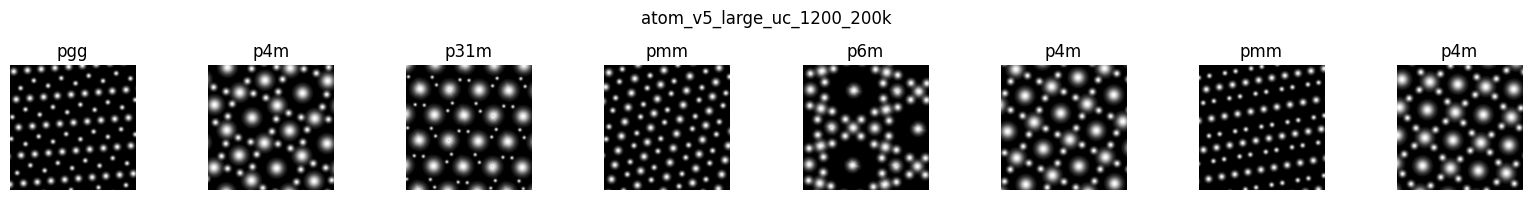

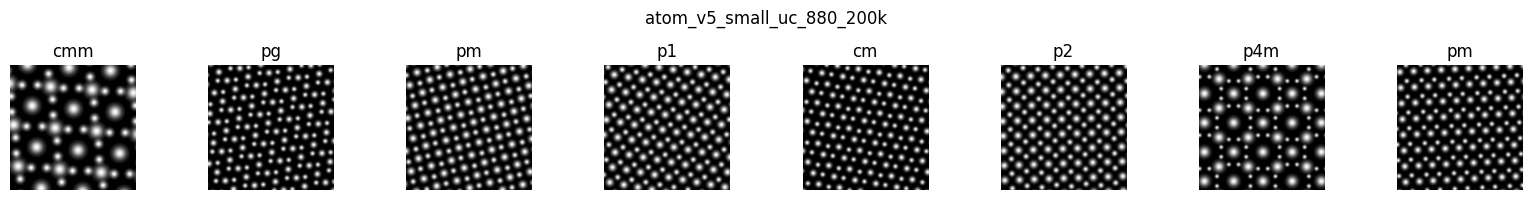

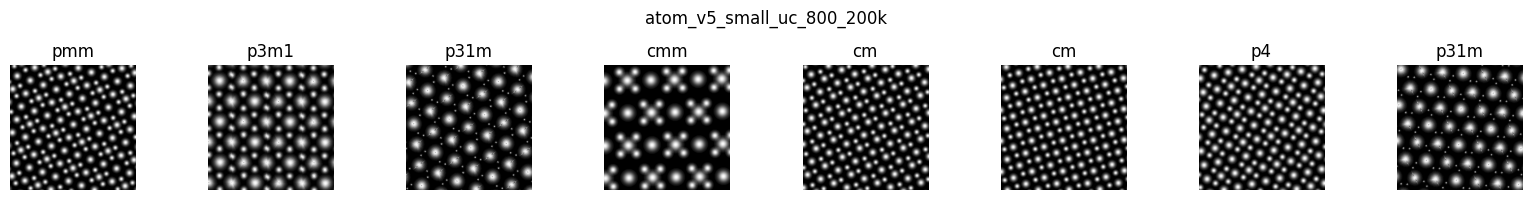

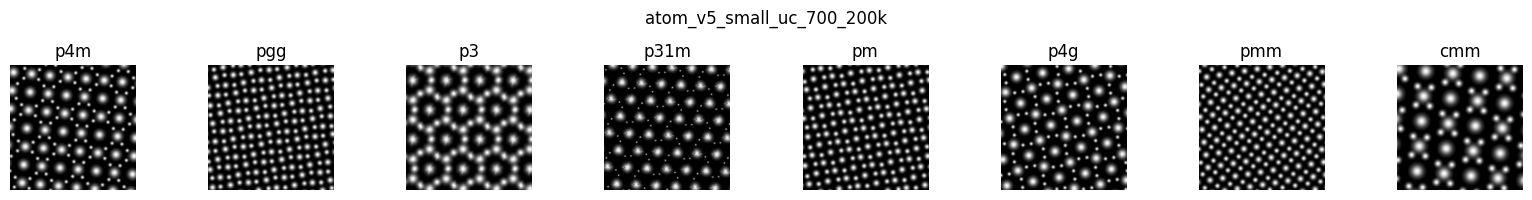

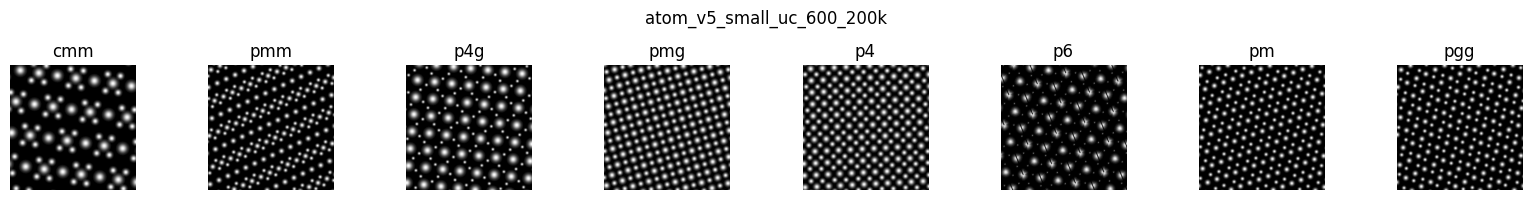

In [12]:
# atom_v5_large_uc_1200_200k
atom_v5_large_uc_1200_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_large_uc_1200_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_large_uc_1200_200k_dl = DataLoader(atom_v5_large_uc_1200_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_large_uc_1200_200k_dl, label_converter=label_converter, title='atom_v5_large_uc_1200_200k')

# atom_v5_small_uc_880_200k
atom_v5_small_uc_880_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_880_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_880_200k_dl = DataLoader(atom_v5_small_uc_880_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_880_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_880_200k')

# atom_v5_small_uc_800_200k
atom_v5_small_uc_800_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_800_200k_dl = DataLoader(atom_v5_small_uc_800_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_800_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_800_200k')

# atom_v5_small_uc_700_200k
atom_v5_small_uc_700_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_700_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_700_200k_dl = DataLoader(atom_v5_small_uc_700_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_700_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_700_200k')

# atom_v5_small_uc_600_200k
atom_v5_small_uc_600_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_600_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_600_200k_dl = DataLoader(atom_v5_small_uc_600_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_600_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_600_200k')

plt.show()

### generate confusion matrix

In [13]:
keywords = ['atom_v5_large_uc_1200_200k', 'atom_v5_small_uc_880_200k', 'atom_v5_small_uc_800_200k', 'atom_v5_small_uc_700_200k', 'atom_v5_small_uc_600_200k']
dl_list = [atom_v5_large_uc_1200_200k_dl, atom_v5_small_uc_880_200k_dl, atom_v5_small_uc_800_200k_dl, atom_v5_small_uc_700_200k_dl, atom_v5_small_uc_600_200k_dl]

for name, dl in zip(keywords, dl_list):
    cm = confusion_matrix(model, dl, symmetry_classes, device, n_batches='all')
    np.save(f'../../saved_results/Dataset_benchmark/resnet50-{name}_cm.npy', cm)

100%|██████████| 399/399 [45:04<00:00,  6.78s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0,12002.0


Accuracy for these batches: 19.25806483233187%


100%|██████████| 399/399 [29:29<00:00,  4.44s/it]

...

Accuracy for these batches: 50.56519607843137%


100%|██████████| 399/399 [40:35<00:00,  6.10s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0


Accuracy for these batches: 24.427450980392155%


In [14]:
keywords = ['atom_v5_large_uc_1200_200k', 'atom_v5_small_uc_880_200k', 'atom_v5_small_uc_800_200k', 'atom_v5_small_uc_700_200k', 'atom_v5_small_uc_600_200k']
for k in keywords:
    file = glob.glob(f'../../saved_results/Dataset_benchmark/resnet50-{k}*.npy')[0]
    print(file)
    cm = np.load(file)
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    # plot_cm(cm, symmetry_classes, title=file.split('/')[-1].split('.')[0], cm_style='simple', fig_style='printing', font_size=4)

../../saved_results/Dataset_benchmark/resnet50-atom_v5_large_uc_1200_200k_cm.npy
Accuracy: 19.26%

../../saved_results/Dataset_benchmark/resnet50-atom_v5_small_uc_880_200k_cm.npy
Accuracy: 82.88%

../../saved_results/Dataset_benchmark/resnet50-atom_v5_small_uc_800_200k_cm.npy
Accuracy: 75.41%

../../saved_results/Dataset_benchmark/resnet50-atom_v5_small_uc_700_200k_cm.npy
Accuracy: 50.57%

../../saved_results/Dataset_benchmark/resnet50-atom_v5_small_uc_600_200k_cm.npy
Accuracy: 24.43%



In [ ]:
files = []
for k in keywords:
    files.append(glob.glob(f'../../saved_results/Dataset_benchmark/resnet50-{k}*.npy')[0])
show_cm(files, keywords, summary=True, title_head=None, cm_style='simple', fig_style='printing', font_size=2,
        file_path='../../figures/Dataset_benchmark/ResNet50_cm_uc_comparison')

## compare dataset with smaller uc and dataset using transform function

In [15]:
import h5py

def calculate_uc_area(h5_file, group='test'):
    with h5py.File(h5_file, 'r') as f:
        va = np.array(f[group]['primitive_uc_vector_a'])
        vb = np.array(f[group]['primitive_uc_vector_b'])
        shapes = f[group]['shape']
        shape_dict = { 'rectangular': 0, 'square': 0, 'oblique': 1, 'hexagonal': 1, 'rhombic': 2, 'triangle': 3 }
        shape_dict_inv = {v: k for k, v in shape_dict.items()}  
        shapes = [shape_dict_inv[s] for s in shapes]

    areas = []
    for a, b, shape in zip(va, vb, shapes):
        if shape != 'triangle':
            areas.append(np.linalg.norm(np.cross(a, b)))
        else:
            areas.append(np.linalg.norm(np.cross(a, b)) / 2)
    return areas

import torch
from torchvision import transforms
from PIL import Image

class ZoomTransform:
    def __init__(self, zoom_factor):
        """
        Initialize the ZoomTransform.
        
        Parameters:
        - zoom_factor (float): The zoom factor. Values > 1 will zoom in, values < 1 will zoom out.
        """
        self.zoom_factor = zoom_factor
    
    def __call__(self, image):
        """
        Apply the zoom transform to the image.
        
        Parameters:
        - image (PIL.Image or torch.Tensor): The input image.
        
        Returns:
        - PIL.Image or torch.Tensor: The transformed image.
        """
        if isinstance(image, torch.Tensor):
            image = transforms.ToPILImage()(image)
        
        original_size = image.size
        
        if self.zoom_factor > 1:
            # Zoom in
            new_size = (int(original_size[0] * self.zoom_factor), int(original_size[1] * self.zoom_factor))
            transform = transforms.Compose([
                transforms.Resize(new_size),
                transforms.CenterCrop(original_size)
            ])
        elif self.zoom_factor < 1:
            # Zoom out
            # print(original_size[0] * self.zoom_factor)
            new_size = (int(original_size[0] * self.zoom_factor), int(original_size[1] * self.zoom_factor))
            transform = transforms.Compose([
                transforms.Resize(new_size),
                transforms.Pad(
                    padding=(
                        (original_size[0] - new_size[0]) // 2, 
                        (original_size[1] - new_size[1]) // 2
                    ),
                    padding_mode='constant'
                )
            ])
        else:
            # No zoom, return the original image
            return image
        
        return transform(image)

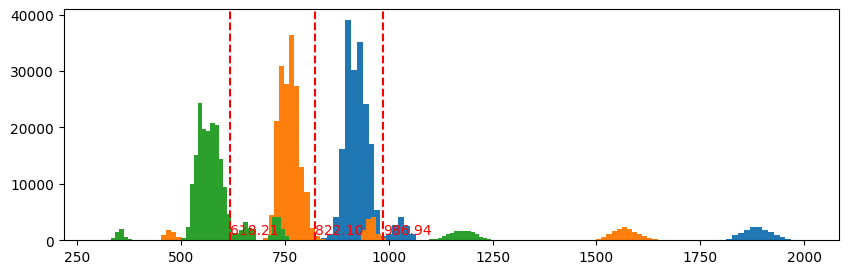

In [16]:
fig, axes = plt.subplots(1, 1, figsize=(10, 3))
areas = calculate_uc_area('../../datasets/symmetry_dataset/atom_v5_rot_200k.h5')
plt.hist(areas, bins=100)
plt.axvline(np.mean(areas), color='r', linestyle='--')
plt.text(np.mean(areas), 1000, f'{np.mean(areas):.2f}', color='r')

areas = calculate_uc_area('../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5')
plt.hist(areas, bins=100)
plt.axvline(np.mean(areas), color='r', linestyle='--')
plt.text(np.mean(areas), 1000, f'{np.mean(areas):.2f}', color='r')

areas = calculate_uc_area('../../datasets/symmetry_dataset/atom_v5_small_uc_600_200k.h5')
plt.hist(areas, bins=100)
plt.axvline(np.mean(areas), color='r', linestyle='--')
plt.text(np.mean(areas), 1000, f'{np.mean(areas):.2f}', color='r')
plt.show()

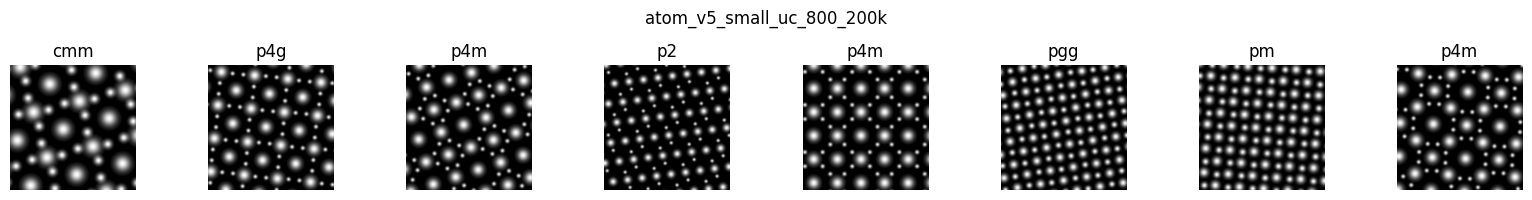

100%|██████████| 3188/3188 [10:24<00:00,  5.10it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0


Accuracy for these batches: 50.24607843137255%


In [20]:
# atom_v5_960_200k
transform = transforms.Compose([
    transforms.ToTensor(), # Convert PIL image to tensor
    ZoomTransform(zoom_factor=960/800), # Apply zoom transform
    # transforms.ToPILImage(), # Convert tensor back to PIL image (if needed for further transforms)
    transforms.ToTensor() # Convert PIL image back to tensor for model input
])

# atom_v5_small_uc_800_200k
atom_v5_small_uc_800_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5', folder='test', transform=transform)
atom_v5_small_uc_800_200k_dl = DataLoader(atom_v5_small_uc_800_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_800_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_800_200k')
plt.show()

name = 'atom_v5_small_uc_800_200k-zoomed_to_960'
cm = confusion_matrix(model, atom_v5_200k_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../saved_results/Dataset_benchmark/resnet50-{name}_cm.npy', cm)